In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df_stud_data = pd.read_csv("playground-series-s6e1/train.csv")

In [3]:
df_stud_data.head()

,id,age,gender,course,study_hours,class_attendance,internet_access,sleep_hours,sleep_quality,study_method,facility_rating,exam_difficulty,exam_score
0,0,21,female,b.sc,7.91,98.8,no,4.9,average,online videos,low,easy,78.3
1,1,18,other,diploma,4.95,94.8,yes,4.7,poor,self-study,medium,moderate,46.7
2,2,20,female,b.sc,4.68,92.6,yes,5.8,poor,coaching,high,moderate,99.0
3,3,19,male,b.sc,2.00,49.5,yes,8.3,average,group study,high,moderate,63.9
4,4,23,male,bca,7.65,86.9,yes,9.6,good,self-study,high,easy,100.0


In [4]:
df_stud_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 630000 entries, 0 to 629999
Data columns (total 13 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   id                630000 non-null  int64  
 1   age               630000 non-null  int64  
 2   gender            630000 non-null  object 
 3   course            630000 non-null  object 
 4   study_hours       630000 non-null  float64
 5   class_attendance  630000 non-null  float64
 6   internet_access   630000 non-null  object 
 7   sleep_hours       630000 non-null  float64
 8   sleep_quality     630000 non-null  object 
 9   study_method      630000 non-null  object 
 10  facility_rating   630000 non-null  object 
 11  exam_difficulty   630000 non-null  object 
 12  exam_score        630000 non-null  float64
dtypes: float64(4), int64(2), object(7)
memory usage: 62.5+ MB


There are no empty fields in the data --- all columns and rows are filled 

In [5]:
df_stud_data.describe()

,id,age,study_hours,class_attendance,sleep_hours,exam_score
count,630000.000000,630000.000000,630000.000000,630000.000000,630000.000000,630000.000000
mean,314999.500000,20.545821,4.002337,71.987261,7.072758,62.506672
std,181865.479132,2.260238,2.359880,17.430098,1.744811,18.916884
min,0.000000,17.000000,0.080000,40.600000,4.100000,19.599000
25%,157499.750000,19.000000,1.970000,57.000000,5.600000,48.800000
50%,314999.500000,21.000000,4.000000,72.600000,7.100000,62.600000
75%,472499.250000,23.000000,6.050000,87.200000,8.600000,76.300000
max,629999.000000,24.000000,7.910000,99.400000,9.900000,100.000000


The mean and the median are quite close to each other --- data seems to be well balanced about the mean !!!  

**Exploratory Data Analysis** 

<Axes: xlabel='exam_score', ylabel='Count'>

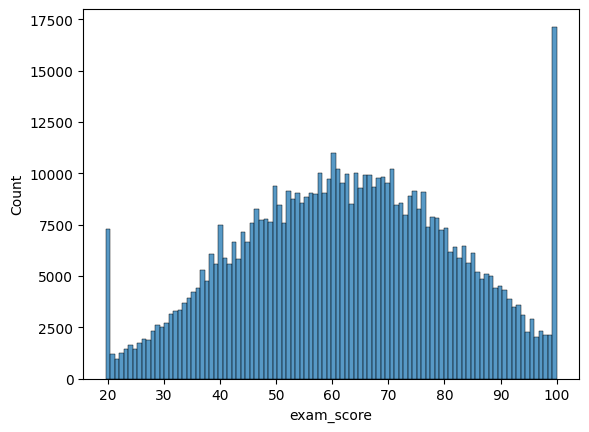

In [6]:
sns.histplot(data=df_stud_data['exam_score'], bins=100)

You can see that the histogram has a histogram that is similar to normal distribution except there is a large number of  
students that have scored 100% and alos large number those who have scored 20%    

<Axes: xlabel='gender', ylabel='exam_score'>

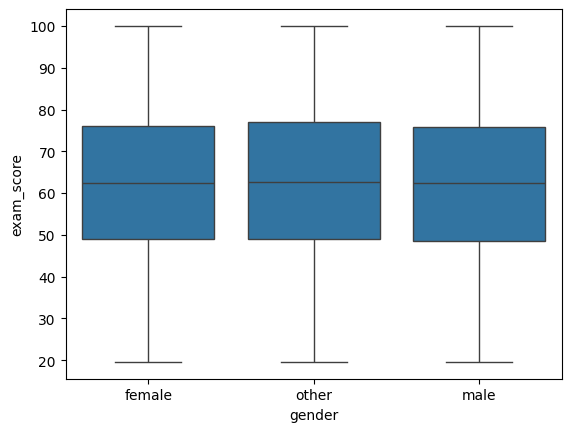

In [7]:
sns.boxplot(data=df_stud_data, x='gender', y='exam_score')

<Axes: xlabel='course', ylabel='exam_score'>

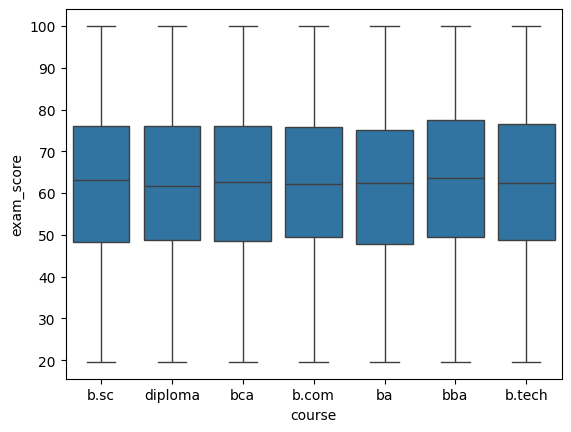

In [18]:
sns.boxplot(data=df_stud_data, x='course', y='exam_score')

<Axes: xlabel='internet_access', ylabel='exam_score'>

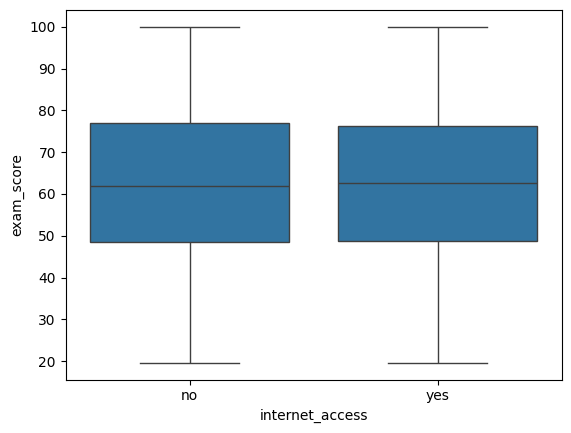

In [19]:
sns.boxplot(data=df_stud_data, x='internet_access', y='exam_score')

<Axes: xlabel='sleep_quality', ylabel='exam_score'>

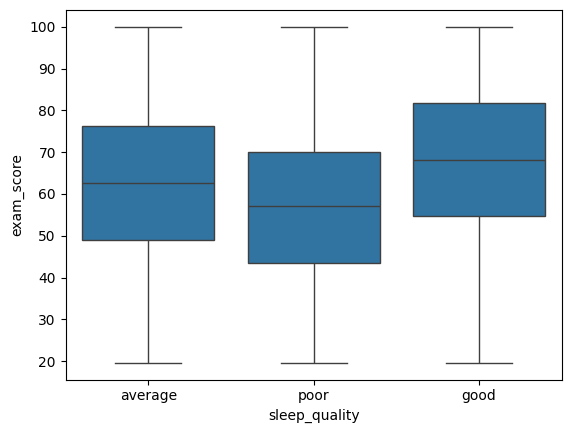

In [20]:
sns.boxplot(data=df_stud_data, x='sleep_quality', y='exam_score')

As we can see above box plots, good sleep quality often has higher median scores.  

<Axes: xlabel='study_method', ylabel='exam_score'>

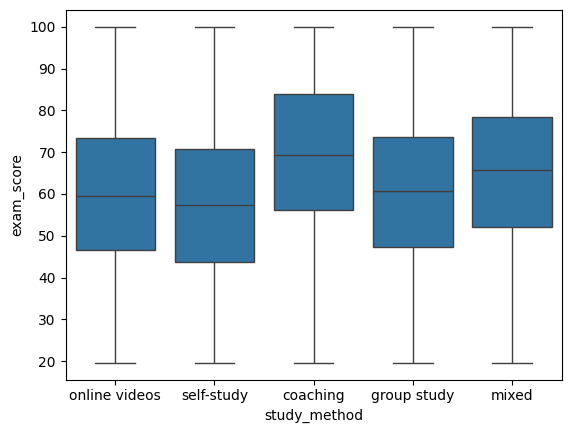

In [23]:
sns.boxplot(data=df_stud_data, x='study_method', y='exam_score')

As we can see that study method = coaching is having higher exam_score than others.  

<Axes: xlabel='facility_rating', ylabel='exam_score'>

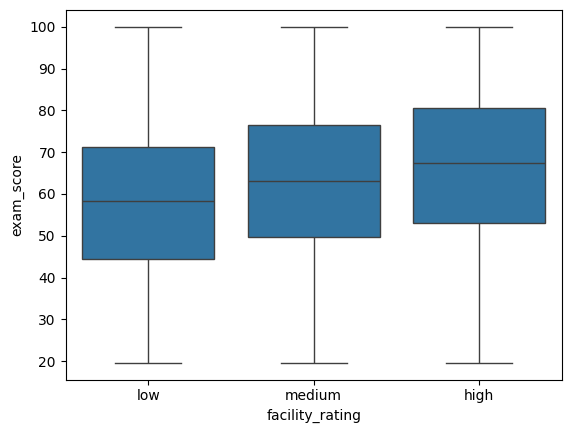

In [8]:
sns.boxplot(data=df_stud_data, x='facility_rating', y='exam_score')

<Axes: xlabel='exam_difficulty', ylabel='exam_score'>

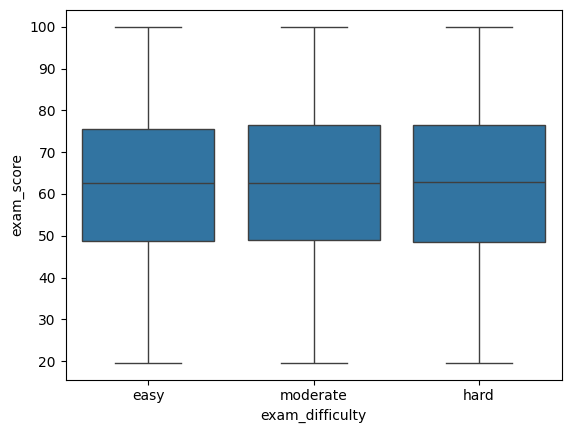

In [9]:
sns.boxplot(data=df_stud_data, x='exam_difficulty', y='exam_score')

As we can see higher facility rating improves the exam scores  
Examp difficulty does not have that much difference in terms of the score statistics.  

Summary of box plots ----
Exam scores are influenced more by these columns --- sleep quality, facility rating and study method.  
Small dependence also on the course. Other params have a very small difference in the statitics.  

<Axes: >

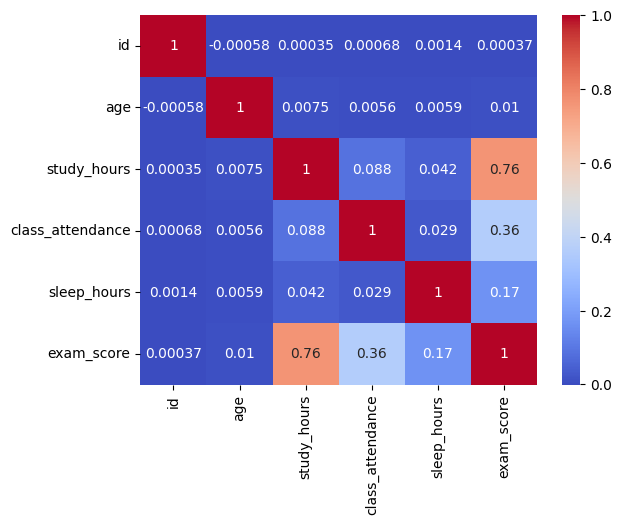

In [13]:
sns.heatmap(df_stud_data.corr(numeric_only=True), annot= True, fmt= '.2g', cmap='coolwarm')

As can be seen from the heat map above, exam_scores are highly correlated with study_hours, class_attendence  
and sleep hours. Based on the box plot analysis following are the most important columns that need to be considered. 

1. sleep_quality
2. study_method
3. facility_rating
4. study_hours
5. class_attendence
6. sleep_hours  
minor influence from  
7. course


**Data Narrowing and Dummies**  

In [15]:
df_stud_data.columns

Index(['id', 'age', 'gender', 'course', 'study_hours', 'class_attendance',
       'internet_access', 'sleep_hours', 'sleep_quality', 'study_method',
       'facility_rating', 'exam_difficulty', 'exam_score'],
      dtype='object')

In [17]:
df_stud_data.drop(labels=['age', 'gender', 'internet_access', 'exam_difficulty'], axis=1, inplace=True)

In [18]:
df_stud_data

,id,course,study_hours,class_attendance,sleep_hours,sleep_quality,study_method,facility_rating,exam_score
0,0,b.sc,7.91,98.8,4.9,average,online videos,low,78.300
1,1,diploma,4.95,94.8,4.7,poor,self-study,medium,46.700
2,2,b.sc,4.68,92.6,5.8,poor,coaching,high,99.000
3,3,b.sc,2.00,49.5,8.3,average,group study,high,63.900
4,4,bca,7.65,86.9,9.6,good,self-study,high,100.000
...,...,...,...,...,...,...,...,...,...
629995,629995,b.tech,4.86,70.7,4.1,good,mixed,high,69.500
629996,629996,ba,7.08,54.4,4.5,average,mixed,low,78.900
629997,629997,bca,0.64,44.2,4.3,poor,online videos,low,19.599
629998,629998,b.com,1.54,75.1,8.2,average,group study,high,59.100


In [19]:
df_stud_data = df_stud_data.set_index('id')

In [20]:
df_stud_data

,course,study_hours,class_attendance,sleep_hours,sleep_quality,study_method,facility_rating,exam_score
id,,,,,,,,
0,b.sc,7.91,98.8,4.9,average,online videos,low,78.300
1,diploma,4.95,94.8,4.7,poor,self-study,medium,46.700
2,b.sc,4.68,92.6,5.8,poor,coaching,high,99.000
3,b.sc,2.00,49.5,8.3,average,group study,high,63.900
4,bca,7.65,86.9,9.6,good,self-study,high,100.000
...,...,...,...,...,...,...,...,...
629995,b.tech,4.86,70.7,4.1,good,mixed,high,69.500
629996,ba,7.08,54.4,4.5,average,mixed,low,78.900
629997,bca,0.64,44.2,4.3,poor,online videos,low,19.599


In [23]:
df_stud_data = pd.get_dummies(data=df_stud_data, columns=['course', 'sleep_quality', 'study_method', 'facility_rating'], 
                       drop_first=True, dtype=float)

In [24]:
df_stud_data

,study_hours,class_attendance,sleep_hours,exam_score,course_b.sc,course_b.tech,course_ba,course_bba,course_bca,course_diploma,sleep_quality_good,sleep_quality_poor,study_method_group study,study_method_mixed,study_method_online videos,study_method_self-study,facility_rating_low,facility_rating_medium
id,,,,,,,,,,,,,,,,,,
0,7.91,98.8,4.9,78.300,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0
1,4.95,94.8,4.7,46.700,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0
2,4.68,92.6,5.8,99.000,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
3,2.00,49.5,8.3,63.900,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
4,7.65,86.9,9.6,100.000,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
629995,4.86,70.7,4.1,69.500,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
629996,7.08,54.4,4.5,78.900,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0
629997,0.64,44.2,4.3,19.599,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0


**Model Training**  

In [25]:
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

In [28]:
X = df_stud_data.drop(labels=['exam_score'], axis=1)
y = df_stud_data['exam_score']

In [29]:
X.head()

,study_hours,class_attendance,sleep_hours,course_b.sc,course_b.tech,course_ba,course_bba,course_bca,course_diploma,sleep_quality_good,sleep_quality_poor,study_method_group study,study_method_mixed,study_method_online videos,study_method_self-study,facility_rating_low,facility_rating_medium
id,,,,,,,,,,,,,,,,,
0,7.91,98.8,4.9,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0
1,4.95,94.8,4.7,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0
2,4.68,92.6,5.8,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
3,2.00,49.5,8.3,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
4,7.65,86.9,9.6,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0


In [30]:
y.head()

id
0     78.3
1     46.7
2     99.0
3     63.9
4    100.0
Name: exam_score, dtype: float64

In [35]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=101)

In [36]:
print(X_train.shape)
print(X_test.shape)

(472500, 17)
(157500, 17)


In [37]:
scaler = MinMaxScaler()

In [38]:
scaler.fit(X_train)

,feature_range,"(0, ...)"
,copy,True
,clip,False


In [39]:
X_train = scaler.transform(X_train)
X_test = scaler.transform(X_test)

In [40]:
model = LinearRegression()

In [41]:
model.fit(X_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


**Model Prediction**  

In [47]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, root_mean_squared_error

In [48]:
y_pred = model.predict(X_test)

In [49]:
y_pred.shape

(157500,)

<Axes: xlabel='exam_score'>

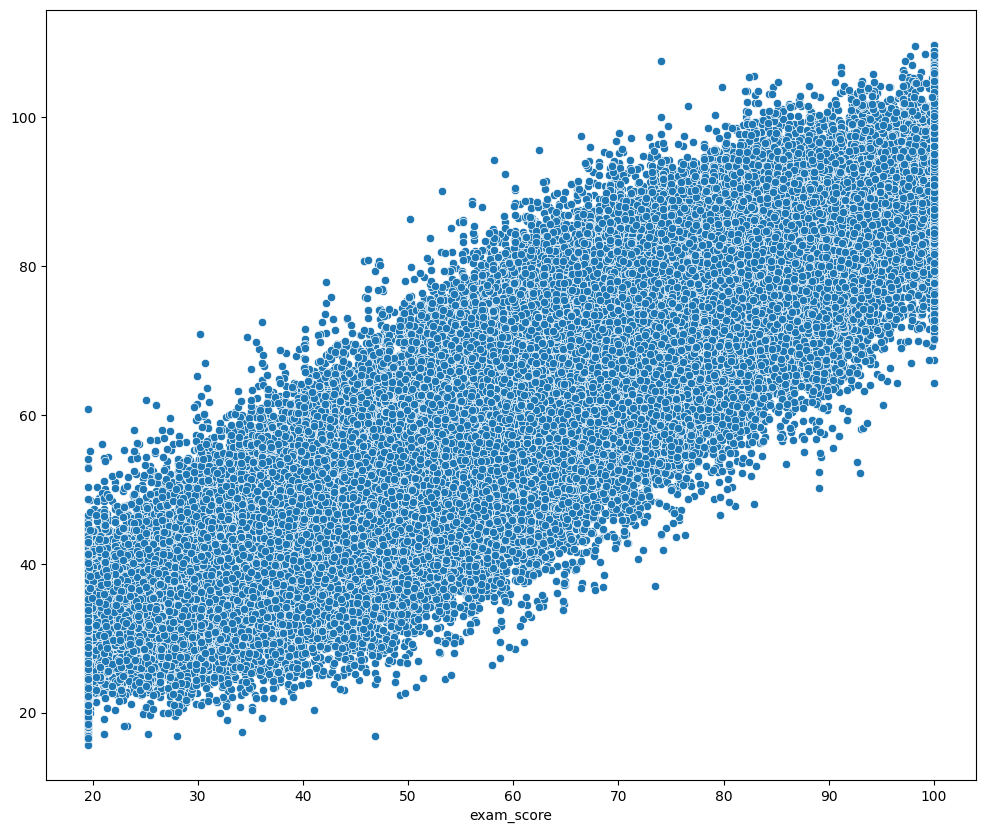

In [55]:
plt.figure(figsize=(12,10))
sns.scatterplot(x=y_test, y=y_pred)

In [58]:
print(f'Mean Absolute Error {mean_absolute_error(y_test, y_pred)}')
print(f'Mean Squared Error {mean_squared_error(y_test, y_pred)}')
print(f'Root Mean Squared Error {root_mean_squared_error(y_test, y_pred)}')

Mean Absolute Error 7.09286803278356
Mean Squared Error 78.79525399151336
Root Mean Squared Error 8.876669082010062


We can see that since the exam scores are always between 0 to 100, a MAE of 7.09% and RMSE of 8.88% isn't bad  
but it isn;t very good either.  The graph plotted above does show 'kind' of linear relation but there are too many points  
to check it accurately. May be we can try to take only 5-10% of points randomly and check if the y_test vs y_pred plot  
is linear.  

In [61]:
type(y_test)

pandas.core.series.Series

In [62]:
type(y_pred)

numpy.ndarray

In [63]:
y_pred_ser = pd.Series(y_pred)

In [66]:
print(y_test)
print(y_pred_ser)

id
523888     62.5
228632     74.2
232010    100.0
261425     87.6
10009      87.9
          ...  
118542     52.4
484548     76.7
615885     69.9
400881     71.2
328166     64.6
Name: exam_score, Length: 157500, dtype: float64
0         60.072518
1         74.287653
2         98.644724
3         83.305863
4         74.032391
            ...    
157495    53.011489
157496    65.365787
157497    60.160253
157498    83.072834
157499    57.816603
Length: 157500, dtype: float64


Now indices of y_test are the id column of original data frame while those of y_pred_ser are just numbers serially.  
We need to remake the series such that it takes id column from the y_test instead of index position of y_pred numpy array  

In [72]:
y_pred_ser = pd.Series(y_pred, index=y_test.index)

In [73]:
print(y_test)
print(y_pred_ser)

id
523888     62.5
228632     74.2
232010    100.0
261425     87.6
10009      87.9
          ...  
118542     52.4
484548     76.7
615885     69.9
400881     71.2
328166     64.6
Name: exam_score, Length: 157500, dtype: float64
id
523888    60.072518
228632    74.287653
232010    98.644724
261425    83.305863
10009     74.032391
            ...    
118542    53.011489
484548    65.365787
615885    60.160253
400881    83.072834
328166    57.816603
Length: 157500, dtype: float64


In [76]:
y_results = pd.concat([y_test, y_pred_ser], axis=1)

In [82]:
y_results.columns = ['exam_score', 'exam_score_predicted']

In [83]:
y_results

,exam_score,exam_score_predicted
id,,
523888,62.5,60.072518
228632,74.2,74.287653
232010,100.0,98.644724
261425,87.6,83.305863
10009,87.9,74.032391
...,...,...
118542,52.4,53.011489
484548,76.7,65.365787
615885,69.9,60.160253


In [91]:
y_results_sample = y_results.sample(frac=0.005)  # take 0.5% of the data only

<Axes: xlabel='exam_score', ylabel='exam_score_predicted'>

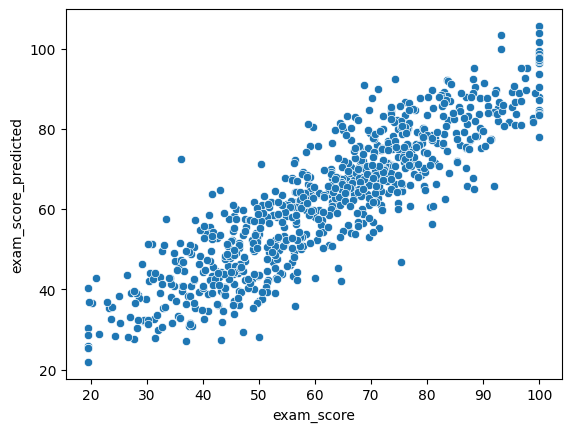

In [92]:
sns.scatterplot(data=y_results_sample, x='exam_score', y='exam_score_predicted')

As we can see from the graph above with lower percentage of samples from the results frame, there are just too many values   
at exam_score = 20 and exam_score = 100.  This can also be verified from the histogram plot. As a result, its better that  
we retrain the model by excluding these outliers completely.  

**Model Retraining without Outliers**  

In [96]:
df_stud_data[(df_stud_data['exam_score'] < 100) & (df_stud_data['exam_score'] > 20)]

,study_hours,class_attendance,sleep_hours,exam_score,course_b.sc,course_b.tech,course_ba,course_bba,course_bca,course_diploma,sleep_quality_good,sleep_quality_poor,study_method_group study,study_method_mixed,study_method_online videos,study_method_self-study,facility_rating_low,facility_rating_medium
id,,,,,,,,,,,,,,,,,,
0,7.91,98.8,4.9,78.3,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0
1,4.95,94.8,4.7,46.7,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0
2,4.68,92.6,5.8,99.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
3,2.00,49.5,8.3,63.9,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
5,5.04,85.1,9.4,70.1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
629994,1.67,73.7,5.9,41.7,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
629995,4.86,70.7,4.1,69.5,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
629996,7.08,54.4,4.5,78.9,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0


<Axes: xlabel='exam_score', ylabel='Count'>

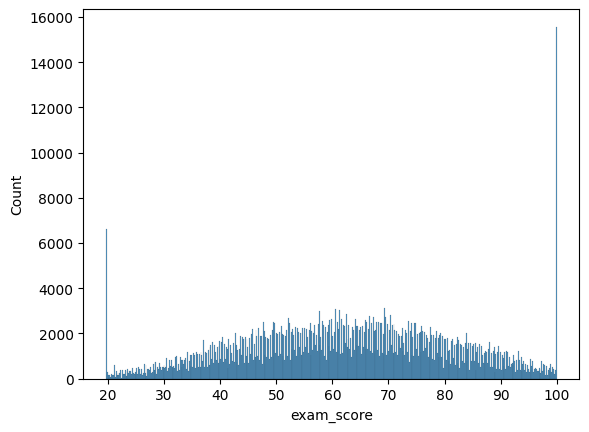

In [97]:
sns.histplot(data=df_stud_data['exam_score'], bins=500)

In [99]:
df_stud_data[(df_stud_data['exam_score']  == 100)]

,study_hours,class_attendance,sleep_hours,exam_score,course_b.sc,course_b.tech,course_ba,course_bba,course_bca,course_diploma,sleep_quality_good,sleep_quality_poor,study_method_group study,study_method_mixed,study_method_online videos,study_method_self-study,facility_rating_low,facility_rating_medium
id,,,,,,,,,,,,,,,,,,
4,7.65,86.9,9.6,100.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
12,7.40,92.4,8.2,100.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
52,6.66,85.4,5.5,100.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
55,6.76,95.5,6.2,100.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0
65,7.91,73.3,6.6,100.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
629690,6.77,82.8,7.5,100.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0
629789,7.57,95.4,9.7,100.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
629818,7.85,62.1,8.5,100.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0


In [101]:
df_stud_data[(df_stud_data['exam_score']  >= 99.5)]

,study_hours,class_attendance,sleep_hours,exam_score,course_b.sc,course_b.tech,course_ba,course_bba,course_bca,course_diploma,sleep_quality_good,sleep_quality_poor,study_method_group study,study_method_mixed,study_method_online videos,study_method_self-study,facility_rating_low,facility_rating_medium
id,,,,,,,,,,,,,,,,,,
4,7.65,86.9,9.6,100.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
12,7.40,92.4,8.2,100.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
52,6.66,85.4,5.5,100.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
55,6.76,95.5,6.2,100.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0
65,7.91,73.3,6.6,100.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
629789,7.57,95.4,9.7,100.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
629818,7.85,62.1,8.5,100.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0
629826,6.31,95.1,4.2,99.6,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0


In [102]:
df_stud_data[(df_stud_data['exam_score']  == 20)]

,study_hours,class_attendance,sleep_hours,exam_score,course_b.sc,course_b.tech,course_ba,course_bba,course_bca,course_diploma,sleep_quality_good,sleep_quality_poor,study_method_group study,study_method_mixed,study_method_online videos,study_method_self-study,facility_rating_low,facility_rating_medium
id,,,,,,,,,,,,,,,,,,
4804,0.09,91.7,6.7,20.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0
12208,1.97,61.8,6.6,20.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0
16179,1.70,55.4,5.5,20.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,1.0,0.0
23979,1.01,55.2,5.3,20.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0
29772,1.01,55.4,5.3,20.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
600584,1.07,41.4,6.4,20.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0
613189,1.53,91.9,6.9,20.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0
619731,1.45,67.1,5.5,20.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0


In [103]:
df_stud_data[(df_stud_data['exam_score'] <= 20.5)]

,study_hours,class_attendance,sleep_hours,exam_score,course_b.sc,course_b.tech,course_ba,course_bba,course_bca,course_diploma,sleep_quality_good,sleep_quality_poor,study_method_group study,study_method_mixed,study_method_online videos,study_method_self-study,facility_rating_low,facility_rating_medium
id,,,,,,,,,,,,,,,,,,
111,2.36,41.7,5.3,19.599,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0
151,0.08,57.2,4.2,19.599,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0
317,0.08,50.5,5.8,19.599,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,1.0,0.0
447,2.68,42.0,5.3,19.599,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0
461,0.08,40.7,6.1,19.599,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
629743,0.08,46.6,7.3,19.599,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0
629782,0.08,67.8,4.2,19.599,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,1.0,0.0
629800,0.62,48.9,9.2,19.800,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0


In [104]:
df_stud_data[(df_stud_data['exam_score'] <= 21)]

,study_hours,class_attendance,sleep_hours,exam_score,course_b.sc,course_b.tech,course_ba,course_bba,course_bca,course_diploma,sleep_quality_good,sleep_quality_poor,study_method_group study,study_method_mixed,study_method_online videos,study_method_self-study,facility_rating_low,facility_rating_medium
id,,,,,,,,,,,,,,,,,,
111,2.36,41.7,5.3,19.599,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0
151,0.08,57.2,4.2,19.599,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0
163,0.37,71.1,5.4,20.800,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0
317,0.08,50.5,5.8,19.599,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,1.0,0.0
354,1.53,62.0,6.2,20.800,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
629743,0.08,46.6,7.3,19.599,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0
629782,0.08,67.8,4.2,19.599,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,1.0,0.0
629800,0.62,48.9,9.2,19.800,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0


Lets keep all the data where scores range from 20.5 upto 99.5 ... Any thing outside this range is outlier row  

In [105]:
df_stud_data[(df_stud_data['exam_score'] >= 20.5) & (df_stud_data['exam_score'] <= 99.5)]

,study_hours,class_attendance,sleep_hours,exam_score,course_b.sc,course_b.tech,course_ba,course_bba,course_bca,course_diploma,sleep_quality_good,sleep_quality_poor,study_method_group study,study_method_mixed,study_method_online videos,study_method_self-study,facility_rating_low,facility_rating_medium
id,,,,,,,,,,,,,,,,,,
0,7.91,98.8,4.9,78.3,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0
1,4.95,94.8,4.7,46.7,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0
2,4.68,92.6,5.8,99.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
3,2.00,49.5,8.3,63.9,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
5,5.04,85.1,9.4,70.1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
629994,1.67,73.7,5.9,41.7,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
629995,4.86,70.7,4.1,69.5,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
629996,7.08,54.4,4.5,78.9,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0


In [128]:
df_stud_data_engg = df_stud_data[(df_stud_data['exam_score'] >= 20.5) & (df_stud_data['exam_score'] <= 99.5)]

In [129]:
X = df_stud_data_engg.drop(labels=['exam_score'], axis=1)
y = df_stud_data_engg['exam_score']

In [130]:
X.head()

,study_hours,class_attendance,sleep_hours,course_b.sc,course_b.tech,course_ba,course_bba,course_bca,course_diploma,sleep_quality_good,sleep_quality_poor,study_method_group study,study_method_mixed,study_method_online videos,study_method_self-study,facility_rating_low,facility_rating_medium
id,,,,,,,,,,,,,,,,,
0,7.91,98.8,4.9,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0
1,4.95,94.8,4.7,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0
2,4.68,92.6,5.8,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
3,2.00,49.5,8.3,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
5,5.04,85.1,9.4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0


In [131]:
y.head()

id
0    78.3
1    46.7
2    99.0
3    63.9
5    70.1
Name: exam_score, dtype: float64

In [132]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=101)

In [133]:
print(X_train.shape)
print(X_test.shape)

(454920, 17)
(151641, 17)


In [134]:
scaler = MinMaxScaler()

In [135]:
scaler.fit(X_train)

,feature_range,"(0, ...)"
,copy,True
,clip,False


In [136]:
X_train = scaler.transform(X_train)
X_test = scaler.transform(X_test)

In [137]:
model = LinearRegression()

In [138]:
model.fit(X_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


**Retrained Model Prediction**  

In [139]:
y_pred = model.predict(X_test)

In [140]:
print(y_pred.shape)

(151641,)


In [141]:
y_pred_ser = pd.Series(y_pred, index=y_test.index)

In [142]:
print(y_test)
print(y_pred_ser)

id
71733     69.2
239943    42.5
628854    79.2
116459    48.0
615612    56.1
          ... 
412472    34.5
613041    79.2
200287    62.4
467603    82.6
429930    76.0
Name: exam_score, Length: 151641, dtype: float64
id
71733     85.432637
239943    46.013303
628854    75.898022
116459    45.405371
615612    59.488995
            ...    
412472    36.926425
613041    64.424299
200287    51.536129
467603    77.520389
429930    77.784933
Length: 151641, dtype: float64


In [143]:
y_results = pd.concat([y_test, y_pred_ser], axis=1)

In [146]:
y_results.columns = ['exam_score', 'exam_score_pred']

In [147]:
y_results

,exam_score,exam_score_pred
id,,
71733,69.2,85.432637
239943,42.5,46.013303
628854,79.2,75.898022
116459,48.0,45.405371
615612,56.1,59.488995
...,...,...
412472,34.5,36.926425
613041,79.2,64.424299
200287,62.4,51.536129


In [150]:
y_results_sample = y_results.sample(frac=0.005)  # take 0.5% of the data only

<Axes: xlabel='exam_score', ylabel='exam_score_pred'>

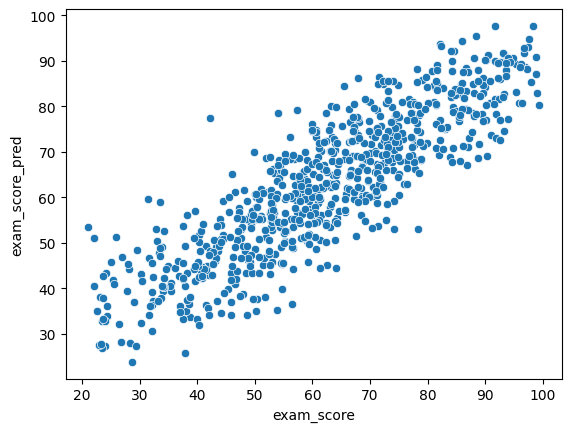

In [151]:
sns.scatterplot(data=y_results_sample, x='exam_score', y='exam_score_pred')

In [152]:
print(f'Mean Absolute Error {mean_absolute_error(y_test, y_pred)}')
print(f'Mean Squared Error {mean_squared_error(y_test, y_pred)}')
print(f'Root Mean Squared Error {root_mean_squared_error(y_test, y_pred)}')

Mean Absolute Error 7.011019362708618
Mean Squared Error 77.0952971878907
Root Mean Squared Error 8.780392769568495


The MAE has very slightly improved from 7.09% to 7.01% and RMSE improved marginally from 8.87% to 8.78%  

**Model Prediction for Problem Test Set**  

In [166]:
df_stud_data_test = pd.read_csv("playground-series-s6e1/test.csv")

In [167]:
df_stud_data_test.head(6)

,id,age,gender,course,study_hours,class_attendance,internet_access,sleep_hours,sleep_quality,study_method,facility_rating,exam_difficulty
0,630000,24,other,ba,6.85,65.2,yes,5.2,poor,group study,high,easy
1,630001,18,male,diploma,6.61,45.0,no,9.3,poor,coaching,low,easy
2,630002,24,female,b.tech,6.60,98.5,yes,6.2,good,group study,medium,moderate
3,630003,24,male,diploma,3.03,66.3,yes,5.7,average,mixed,medium,moderate
4,630004,20,female,b.tech,2.03,42.4,yes,9.2,average,coaching,low,moderate
5,630005,21,male,b.sc,6.22,55.3,yes,4.6,average,mixed,high,moderate


In [168]:
df_stud_data_test.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 270000 entries, 0 to 269999
Data columns (total 12 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   id                270000 non-null  int64  
 1   age               270000 non-null  int64  
 2   gender            270000 non-null  object 
 3   course            270000 non-null  object 
 4   study_hours       270000 non-null  float64
 5   class_attendance  270000 non-null  float64
 6   internet_access   270000 non-null  object 
 7   sleep_hours       270000 non-null  float64
 8   sleep_quality     270000 non-null  object 
 9   study_method      270000 non-null  object 
 10  facility_rating   270000 non-null  object 
 11  exam_difficulty   270000 non-null  object 
dtypes: float64(3), int64(2), object(7)
memory usage: 24.7+ MB


In [169]:
df_stud_data_test.describe()

,id,age,study_hours,class_attendance,sleep_hours
count,270000.000000,270000.000000,270000.000000,270000.000000,270000.000000
mean,764999.500000,20.544137,4.003878,71.982509,7.072070
std,77942.430678,2.260452,2.357741,17.414695,1.745513
min,630000.000000,17.000000,0.080000,40.600000,4.100000
25%,697499.750000,19.000000,1.980000,57.000000,5.600000
50%,764999.500000,21.000000,4.010000,72.600000,7.100000
75%,832499.250000,23.000000,6.050000,87.200000,8.600000
max,899999.000000,24.000000,7.910000,99.400000,9.900000


In [170]:
df_stud_data_test = df_stud_data_test.set_index('id')

In [171]:
df_stud_data_test.head()

,age,gender,course,study_hours,class_attendance,internet_access,sleep_hours,sleep_quality,study_method,facility_rating,exam_difficulty
id,,,,,,,,,,,
630000,24,other,ba,6.85,65.2,yes,5.2,poor,group study,high,easy
630001,18,male,diploma,6.61,45.0,no,9.3,poor,coaching,low,easy
630002,24,female,b.tech,6.60,98.5,yes,6.2,good,group study,medium,moderate
630003,24,male,diploma,3.03,66.3,yes,5.7,average,mixed,medium,moderate
630004,20,female,b.tech,2.03,42.4,yes,9.2,average,coaching,low,moderate


In [172]:
df_stud_data_test.drop(labels=['age', 'gender', 'internet_access', 'exam_difficulty'], axis=1, inplace=True)

In [173]:
df_stud_data_test.head(9)

,course,study_hours,class_attendance,sleep_hours,sleep_quality,study_method,facility_rating
id,,,,,,,
630000,ba,6.85,65.2,5.2,poor,group study,high
630001,diploma,6.61,45.0,9.3,poor,coaching,low
630002,b.tech,6.60,98.5,6.2,good,group study,medium
630003,diploma,3.03,66.3,5.7,average,mixed,medium
630004,b.tech,2.03,42.4,9.2,average,coaching,low
630005,b.sc,6.22,55.3,4.6,average,mixed,high
630006,ba,3.59,91.6,7.7,good,mixed,medium
630007,b.sc,3.14,82.7,4.2,average,online videos,high
630008,diploma,6.49,86.0,7.3,poor,group study,high


In [174]:
df_stud_data_test = pd.get_dummies(data=df_stud_data_test, columns=['course', 'sleep_quality', 'study_method', 'facility_rating'], 
                       drop_first=True, dtype=float)

In [175]:
df_stud_data_test.head(11)

,study_hours,class_attendance,sleep_hours,course_b.sc,course_b.tech,course_ba,course_bba,course_bca,course_diploma,sleep_quality_good,sleep_quality_poor,study_method_group study,study_method_mixed,study_method_online videos,study_method_self-study,facility_rating_low,facility_rating_medium
id,,,,,,,,,,,,,,,,,
630000,6.85,65.2,5.2,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0
630001,6.61,45.0,9.3,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0
630002,6.60,98.5,6.2,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0
630003,3.03,66.3,5.7,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0
630004,2.03,42.4,9.2,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
630005,6.22,55.3,4.6,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
630006,3.59,91.6,7.7,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0
630007,3.14,82.7,4.2,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
630008,6.49,86.0,7.3,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0


Apply Scaler Transformation to the quiz test data  

In [177]:
X_quiz = scaler.transform(df_stud_data_test)

In [178]:
X_quiz

array([[0.86462324, 0.41836735, 0.18965517, ..., 0.        , 0.        ,
        0.        ],
       [0.8339719 , 0.07482993, 0.89655172, ..., 0.        , 1.        ,
        0.        ],
       [0.83269476, 0.98469388, 0.36206897, ..., 0.        , 0.        ,
        1.        ],
       ...,
       [0.83524904, 0.57993197, 0.24137931, ..., 0.        , 0.        ,
        0.        ],
       [0.51085568, 0.19047619, 0.79310345, ..., 0.        , 0.        ,
        0.        ],
       [0.73818646, 0.32482993, 0.82758621, ..., 0.        , 0.        ,
        1.        ]], shape=(270000, 17))

In [179]:
y_quiz_pred = model.predict(X_quiz)

In [180]:
print(y_quiz_pred)

[71.24739004 69.34341451 86.48271006 ... 89.04754579 55.46488765
 68.25377552]


In [186]:
y_quiz_pred = pd.Series(data=y_quiz_pred, index=df_stud_data_test.index)

In [187]:
y_quiz_pred

id
630000    71.247390
630001    69.343415
630002    86.482710
630003    55.160550
630004    47.754126
            ...    
899995    60.630922
899996    39.751941
899997    89.047546
899998    55.464888
899999    68.253776
Length: 270000, dtype: float64

In [190]:
y_quiz_pred = y_quiz_pred.apply(lambda x: np.round(x, 2))

In [191]:
y_quiz_pred

id
630000    71.25
630001    69.34
630002    86.48
630003    55.16
630004    47.75
          ...  
899995    60.63
899996    39.75
899997    89.05
899998    55.46
899999    68.25
Length: 270000, dtype: float64

In [192]:
y_quiz_pred.shape

(270000,)

In [195]:
y_quiz_pred = y_quiz_pred.reset_index()

In [196]:
y_quiz_pred

,id,0
0,630000,71.25
1,630001,69.34
2,630002,86.48
3,630003,55.16
4,630004,47.75
...,...,...
269995,899995,60.63
269996,899996,39.75
269997,899997,89.05
269998,899998,55.46


In [199]:
y_quiz_pred.columns = ['id', 'exam_score']

In [200]:
y_quiz_pred.head(6)

,id,exam_score
0,630000,71.25
1,630001,69.34
2,630002,86.48
3,630003,55.16
4,630004,47.75
5,630005,71.19


In [201]:
y_quiz_pred.to_csv('playground-series-s6e1/submission.csv')